In [1]:
import duckdb
import pandas as pd
import os
import numpy as np
from dotenv import load_dotenv
import json
from collections import defaultdict
from matplotlib.lines import Line2D

# --- CONFIGURAÇÕES GLOBAIS DE AMBIENTE E FILTROS ---
load_dotenv()
data_inicio = os.getenv("DATA_INICIO")
data_fim = os.getenv("DATA_FIM")
curso_id = os.getenv("CURSO_ID")

usuarios_ignorados = "('0', '-1', '', 'nan', 'user6442803380426375169', 'user8540069828419911681')" 

filtro_curso_periodo = (
    f"(courseid = '{curso_id}' OR courseid = '0') AND "
    f"CAST(timecreated AS BIGINT) BETWEEN "
    f"epoch(TIMESTAMP '{data_inicio} 00:00:00') AND "
    f"epoch(TIMESTAMP '{data_fim} 23:59:59')"
)

print("🦆 Extraindo Logs de Interação (Cruzando com Módulos para achar as Seções)...")
pasta_dados = "export/" 

query_logs = f"""
    SELECT logs.timecreated, logs.username, logs.eventname, logs.action, 
           logs.component, logs.contextinstanceid, logs.courseid, cm.section AS section
    FROM read_csv_auto('{pasta_dados}limpo_mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    LEFT JOIN read_csv_auto('{pasta_dados}mdl_course_modules.csv', ALL_VARCHAR=TRUE) AS cm
        ON logs.contextinstanceid = cm.id
    WHERE logs.username NOT IN {usuarios_ignorados}
      AND logs.username IS NOT NULL
      AND {filtro_curso_periodo}  
    ORDER BY CAST(logs.timecreated AS BIGINT) ASC
"""
df_logs = duckdb.query(query_logs).df()

def load_statements_from_file(filename="statements.json", folder="data"):
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"O arquivo {filepath} não foi encontrado.")

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Se for um dicionário com chave "statements", pega apenas essa parte
    if isinstance(data, dict) and "statements" in data:
        return data["statements"]

    # Se for uma lista, retorna direto
    if isinstance(data, list):
        return data

    # Caso inesperado
    raise ValueError("Formato de arquivo JSON inválido. Esperado lista ou dicionário com 'statements'.")

def analisar_dataset_moodle(df):
    print("📊 --- RADIOGRAFIA DO CURSO 'TEACHING WITH MOODLE' --- 📊\n")
    
    # 1. Total de Eventos
    total_eventos = len(df)
    print(f"🔹 Total de Interações (Logs): {total_eventos:,}".replace(',', '.'))
    
    # 2. Total de Alunos Únicos
    alunos_validos = df[~df['username'].isin(['0', '-1', 'nan', 'None', ''])]
    total_alunos = alunos_validos['username'].nunique()
    print(f"👨‍🎓 Total de Alunos Únicos: {total_alunos:,}".replace(',', '.'))
    
    # 3. Total de Seções (Tópicos/Semanas do Curso)
    # Filtramos os nulos para contar apenas seções reais resultantes do JOIN
    secoes_validas = df[~df['section'].isin(['0', 'nan', 'None', '', None]) & df['section'].notna()]
    total_secoes = secoes_validas['section'].nunique()
    print(f"🗂️ Total de Seções (Tópicos do Curso): {total_secoes:,}".replace(',', '.'))
    
    # 4. Total de Atividades Únicas
    atividades_validas = df[~df['contextinstanceid'].isin(['0', 'nan', 'None', ''])]
    total_atividades = atividades_validas['contextinstanceid'].nunique()
    print(f"📝 Total de Instâncias (Atividades Diferentes): {total_atividades:,}".replace(',', '.'))
    
    print("\n🏆 --- TOP 5 EVENTOS MAIS COMUNS --- 🏆")
    top_eventos = df['eventname'].value_counts().head(5)
    for evento, qtd in top_eventos.items():
        # Limpa o nome do evento para ficar mais legível no notebook
        nome_limpo = str(evento).replace('\\', ' > ').strip(' > ')
        print(f"   - {nome_limpo}: {qtd:,}".replace(',', '.'))
        
    print("\n🧩 --- TOP 5 COMPONENTES MAIS ACESSADOS --- 🧩")
    top_componentes = df['component'].value_counts().head(5)
    for comp, qtd in top_componentes.items():
        print(f"   - {str(comp).replace('mod_', '').title()}: {qtd:,}".replace(',', '.'))

# Executa a análise no DataFrame isolado com a coluna section real
analisar_dataset_moodle(df_logs)

🦆 Extraindo Logs de Interação (Cruzando com Módulos para achar as Seções)...
📊 --- RADIOGRAFIA DO CURSO 'TEACHING WITH MOODLE' --- 📊

🔹 Total de Interações (Logs): 1.020.851
👨‍🎓 Total de Alunos Únicos: 2.160
🗂️ Total de Seções (Tópicos do Curso): 6
📝 Total de Instâncias (Atividades Diferentes): 2.348

🏆 --- TOP 5 EVENTOS MAIS COMUNS --- 🏆
   - core > event > message_sent: 181.962
   - core > event > webservice_function_called: 141.125
   - core > event > course_viewed: 98.081
   - core > event > message_viewed: 87.307
   - mod_book > event > chapter_viewed: 68.078

🧩 --- TOP 5 COMPONENTES MAIS ACESSADOS --- 🧩
   - Core: 644.587
   - Forum: 135.916
   - Book: 80.996
   - Quiz: 39.653
   - Page: 27.726


In [2]:


query_cursos_reais = fquery_logs = f"""
        SELECT logs.timecreated, logs.username, logs.eventname, logs.action, 
            logs.component, logs.contextinstanceid, logs.courseid, cm.section AS section
    FROM read_csv_auto('{pasta_dados}limpo_mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    LEFT JOIN read_csv_auto('{pasta_dados}mdl_course_modules.csv', ALL_VARCHAR=TRUE) AS cm
        ON logs.contextinstanceid = cm.id
    WHERE logs.username NOT IN ('0', '-1', '', 'nan') AND logs.username IS NOT NULL
    AND {filtro_curso_periodo}
    ORDER BY CAST(logs.timecreated AS BIGINT) ASC
"""
df_cursos = duckdb.query(query_cursos_reais).df()


In [3]:
quantas_complecoes = f"""
    SELECT 
        COUNT(DISTINCT logs.id) as qtd_complecoes
    FROM read_csv_auto('{pasta_dados}limpo_mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    WHERE logs.username NOT IN ('0', '-1', '', 'nan') 
      AND {filtro_curso_periodo}
      AND logs.eventname = '\\mod_quiz\\event\\attempt_submitted'
      AND logs.contextinstanceid = '54994'
    GROUP BY logs.courseid
"""

df_cursos = duckdb.query(quantas_complecoes).df()
display(df_cursos)

,qtd_complecoes
0,1762


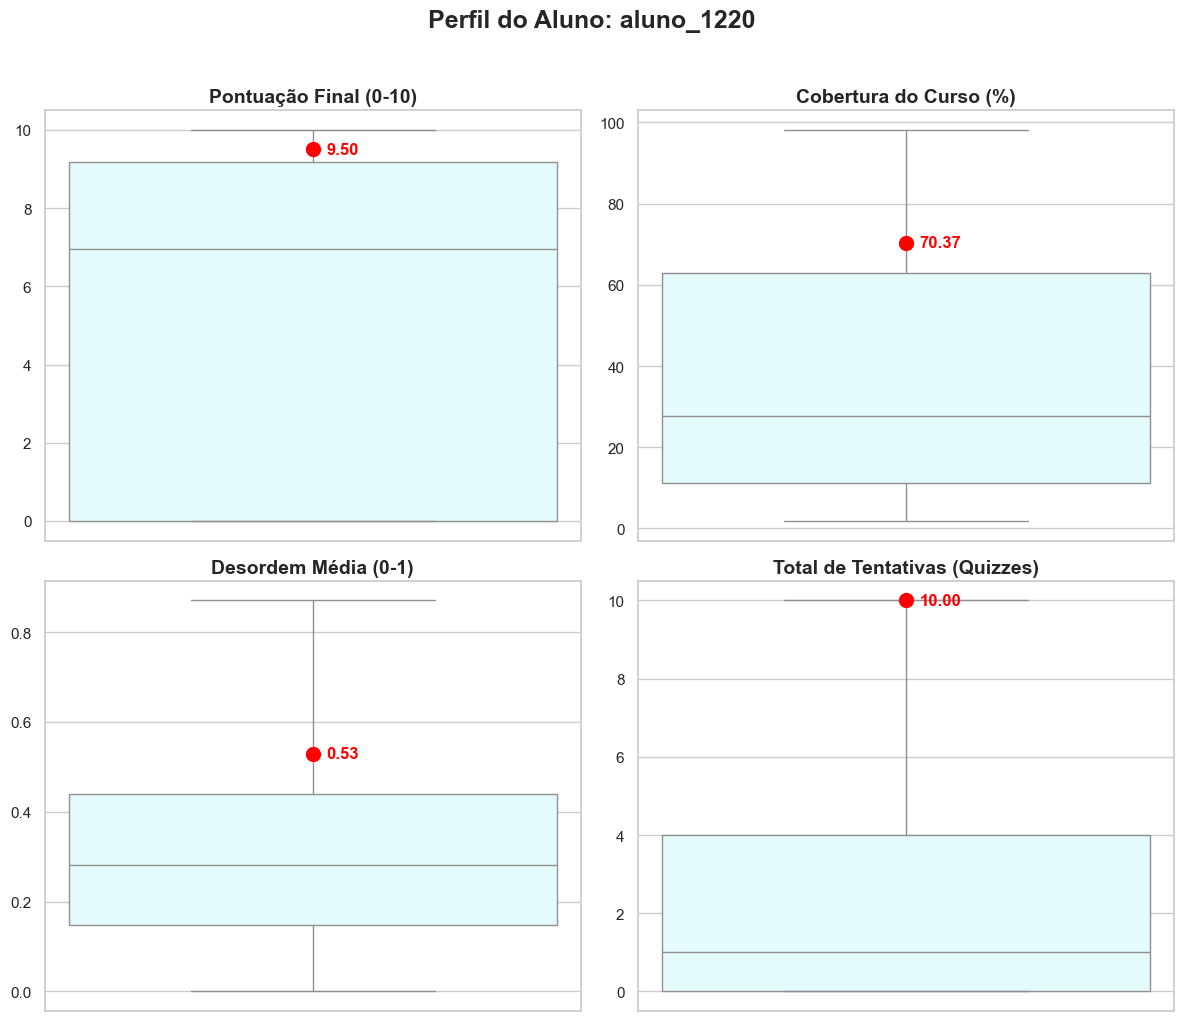

In [4]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Carrega as variáveis de ambiente
load_dotenv(override=True)

# Puxa o caminho da pasta de dados do arquivo .env
export_path = os.getenv("PASTA_DADOS")

# Definição dinâmica dos caminhos
atividades_path = os.path.join(export_path, "atividades.json")
nivel_desordem_path = os.path.join(export_path, "nivel_desordem.json")
visualizacoes_por_objeto_path = os.path.join(export_path, "visualizacoes_por_objeto.json")
proporcao_visualizacoes_path = os.path.join(export_path, "proporcao_visualizacoes_por_atividade.json")
pontuacao_path = os.path.join(export_path, "pontuacao.json")
porcentagem_curso_path = os.path.join(export_path, "porcentagem_curso_acessada.json")
tentativas_por_questionario_path = os.path.join(export_path, "tentativas_por_questionario.json")
tempo_resposta_path = os.path.join(export_path, "tempo_resposta.json")
tempo_total_gasto_em_visitas_reais_path = os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")

# Configuração visual do gráfico
sns.set_theme(style="whitegrid")

def gerar_boxplot_aluno(aluno_alvo):
    # ==========================================
    # 1. CARREGAMENTO E EXTRAÇÃO DAS MÉTRICAS
    # ==========================================
    
    # 1.1 Pontuação
    with open(pontuacao_path, 'r', encoding='utf-8') as f:
        pont_data = json.load(f)
    df_pont = pd.DataFrame(pont_data)[['usuario', 'pontuacao']]
    
    # 1.2 Porcentagem do Curso Acessada
    with open(porcentagem_curso_path, 'r', encoding='utf-8') as f:
        perc_data = json.load(f)
    records_perc = []
    for user, data in perc_data.get('Course 10464', {}).items():
        records_perc.append({'usuario': user, 'porcentagem_acessada': data.get('geral', 0)})
    df_perc = pd.DataFrame(records_perc)
    
    # 1.3 Nível de Desordem (Calculando a média das sessões do aluno)
    with open(nivel_desordem_path, 'r', encoding='utf-8') as f:
        desordem_data = json.load(f)
    desordem_records = {}
    for sessao, s_data in desordem_data.get('Course 10464', {}).get('sessoes', {}).items():
        usuarios = s_data.get('nivel_desordem_por_usuario', {})
        for u, val in usuarios.items():
            desordem_records.setdefault(u, []).append(val)
    df_desordem = pd.DataFrame([
        {'usuario': u, 'desordem_media': sum(vals)/len(vals)} 
        for u, vals in desordem_records.items()
    ])
    
    # 1.4 Tentativas por Questionário (Somando o total do aluno)
    with open(tentativas_por_questionario_path, 'r', encoding='utf-8') as f:
        tentativas_data = json.load(f)
    df_tentativas = pd.DataFrame(tentativas_data)
    df_tentativas = df_tentativas.groupby('usuario')['total_tentativas'].sum().reset_index()

    # ==========================================
    # 2. MERGE (UNINDO TODAS AS MÉTRICAS)
    # ==========================================
    df_final = df_pont.merge(df_perc, on='usuario', how='outer')\
                      .merge(df_desordem, on='usuario', how='outer')\
                      .merge(df_tentativas, on='usuario', how='outer')
    
    # Preenche com 0 caso o aluno não tenha registro em alguma métrica
    df_final = df_final.fillna(0)

    # ==========================================
    # 3. GERAÇÃO DOS BOX PLOTS
    # ==========================================
    # Define as métricas e seus respectivos títulos de forma pareada
    configuracoes = [
        ('pontuacao', 'Pontuação Final (0-10)'),
        ('porcentagem_acessada', 'Cobertura do Curso (%)'),
        ('desordem_media', 'Desordem Média (0-1)'),
        ('total_tentativas', 'Total de Tentativas (Quizzes)')
    ]

    # Cria o grid 2x2: figsize=(largura, altura) aumentado para dar espaço
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Perfil do Aluno: {aluno_alvo}", fontsize=18, fontweight='bold', y=1.02)

    # Achata a matriz de eixos para iterar facilmente (de 2x2 para [ax1, ax2, ax3, ax4])
    axes_flat = axes.flatten()

    aluno_existe = aluno_alvo in df_final['usuario'].values

    for i, (metrica, titulo) in enumerate(configuracoes):
        ax = axes_flat[i]
        
        # Desenha o Box Plot da turma
        sns.boxplot(y=df_final[metrica], ax=ax, color='lightcyan', width=0.4, showfliers=False)
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_ylabel("")
        
        # Destaca o aluno alvo se ele existir nos dados
        if aluno_existe:
            valor_alvo = df_final[df_final['usuario'] == aluno_alvo][metrica].values[0]
            # Ponto vermelho no gráfico
            ax.plot(0, valor_alvo, marker='o', color='red', markersize=10, zorder=10)
            # Anotação com o valor ao lado do ponto
            ax.annotate(f'{valor_alvo:.2f}', 
                        xy=(0, valor_alvo), 
                        xytext=(10, 0), 
                        textcoords='offset points', 
                        color='red', 
                        weight='bold', 
                        fontsize=12,
                        va='center')

    # Ajusta o layout para evitar sobreposição e salvar em alta qualidade
    plt.tight_layout()

    # Salva a imagem para o seu documento (DPI 300 para qualidade acadêmica)
    plt.savefig(os.path.join(export_path, "resultado.png"), dpi=300, bbox_inches='tight')

    plt.show()

# Chama a função
gerar_boxplot_aluno("aluno_1220")

📥 Extraindo métricas...
🔄 Unindo bases de dados...
✅ Imagem salva com sucesso em: export\resultado.png


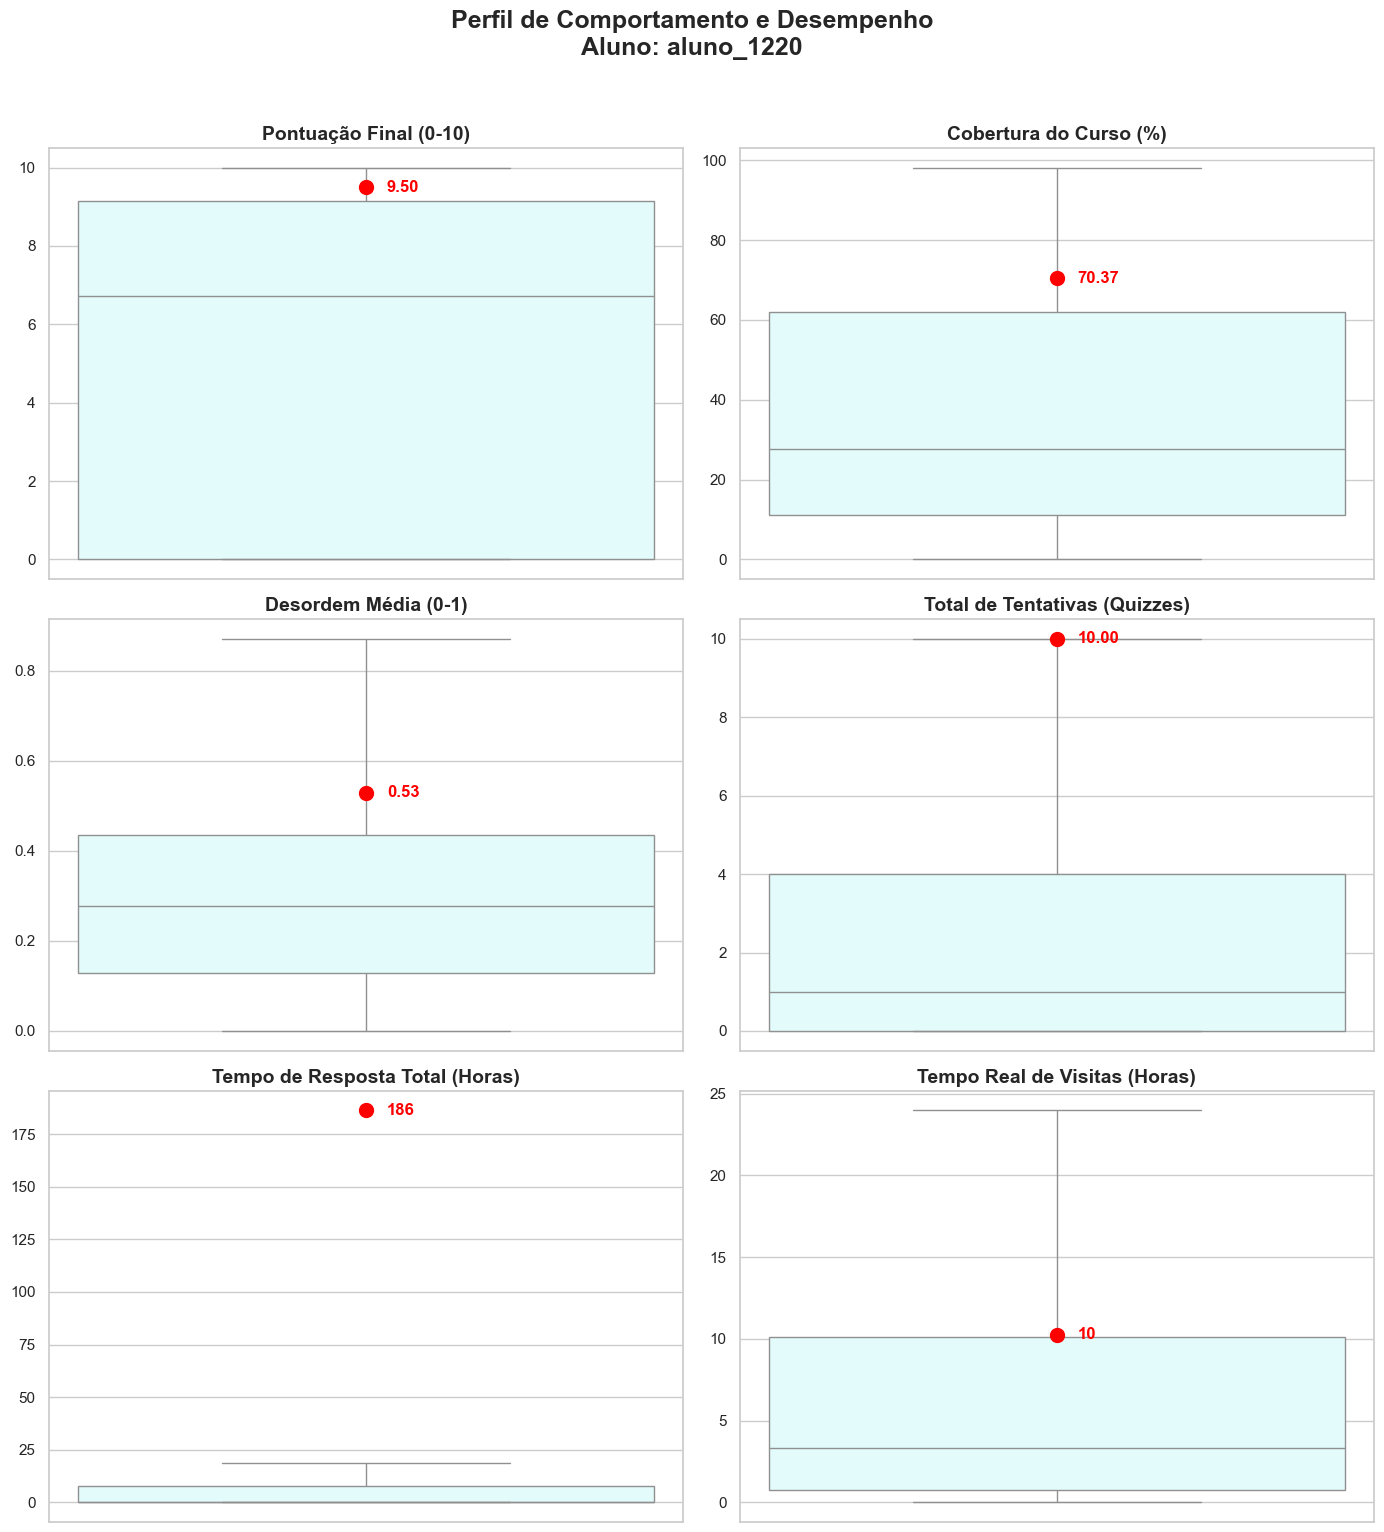


--- Tabela de Valores do Aluno Alvo ---


,usuario,pontuacao,porcentagem_acessada,desordem_media,total_tentativas,soma_tempo_resposta_horas,soma_tempo_total_horas
246,aluno_1220,9.5,70.37,0.52942,10.0,186.235556,10.2625


In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functools import reduce
from dotenv import load_dotenv

# ==========================================
# 0. CONFIGURAÇÕES INICIAIS
# ==========================================
load_dotenv(override=True)
export_path = os.getenv("PASTA_DADOS", "export/")
sns.set_theme(style="whitegrid")

# ==========================================
# 1. FUNÇÕES DE EXTRAÇÃO DE MÉTRICAS
# ==========================================

def extrair_pontuacao(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data)[['usuario', 'pontuacao']]

def extrair_porcentagem(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    records = [{'usuario': user, 'porcentagem_acessada': d.get('geral', 0)} 
               for user, d in data.get('Course 10464', {}).items()]
    return pd.DataFrame(records)

def extrair_desordem(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    records = {}
    for sessao, s_data in data.get('Course 10464', {}).get('sessoes', {}).items():
        for u, val in s_data.get('nivel_desordem_por_usuario', {}).items():
            records.setdefault(u, []).append(val)
    return pd.DataFrame([
        {'usuario': u, 'desordem_media': sum(vals)/len(vals)} 
        for u, vals in records.items()
    ])

def extrair_tentativas(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    return df.groupby('usuario')['total_tentativas'].sum().reset_index()

def extrair_tempo_resposta(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    
    # Regex para extrair Dias, Horas, Minutos e Segundos do formato ISO (PT1M30S)
    regex = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    extraido = df['tempo_resposta'].str.extract(regex).fillna(0).astype(int)
    
    # Converte tudo para segundos inteiros
    df['tempo_resposta_horas'] = (extraido[0]*86400 + extraido[1]*3600 + extraido[2]*60 + extraido[3]) / 3600.0

    # Soma o tempo de todas as atividades por usuário
    df_agrupado = df.groupby('usuario')['tempo_resposta_horas'].sum().reset_index()
    return df_agrupado.rename(columns={'tempo_resposta_horas': 'soma_tempo_resposta_horas'})

def extrair_tempo_real(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    
    regex = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    extraido = df['tempo_passado'].str.extract(regex).fillna(0).astype(int)
    
    # Calcula os segundos e divide por 3600 para transformar em HORAS decimais
    df['tempo_passado_horas'] = (extraido[0]*86400 + extraido[1]*3600 + extraido[2]*60 + extraido[3]) / 3600.0
    
    # Soma o tempo real de visitas (agora em horas)
    df_agrupado = df.groupby('usuario')['tempo_passado_horas'].sum().reset_index()
    
    # Renomeia a coluna para refletir a nova unidade de medida
    return df_agrupado.rename(columns={'tempo_passado_horas': 'soma_tempo_total_horas'})

# ==========================================
# 2. FUNÇÃO PRINCIPAL DE GERAÇÃO DO GRÁFICO
# ==========================================

def gerar_boxplot_aluno(aluno_alvo):
    # Definindo caminhos
    caminhos = {
        'pontuacao': os.path.join(export_path, "pontuacao.json"),
        'porcentagem': os.path.join(export_path, "porcentagem_curso_acessada.json"),
        'desordem': os.path.join(export_path, "nivel_desordem.json"),
        'tentativas': os.path.join(export_path, "tentativas_por_questionario.json"),
        'tempo_resp': os.path.join(export_path, "tempo_resposta.json"),
        'tempo_real': os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")
    }

    print("📥 Extraindo métricas...")
    dfs = [
        extrair_pontuacao(caminhos['pontuacao']),
        extrair_porcentagem(caminhos['porcentagem']),
        extrair_desordem(caminhos['desordem']),
        extrair_tentativas(caminhos['tentativas']),
        extrair_tempo_resposta(caminhos['tempo_resp']),
        extrair_tempo_real(caminhos['tempo_real'])
    ]

    
    print("🔄 Unindo bases de dados...")
    # Une todos os DataFrames pelo 'usuario'
    df_final = reduce(lambda left, right: pd.merge(left, right, on='usuario', how='outer'), dfs)
    df_final = df_final.fillna(0)

    # Configurações do Grid 3x2
    configuracoes = [
        ('pontuacao', 'Pontuação Final (0-10)'),
        ('porcentagem_acessada', 'Cobertura do Curso (%)'),
        ('desordem_media', 'Desordem Média (0-1)'),
        ('total_tentativas', 'Total de Tentativas (Quizzes)'),
        ('soma_tempo_resposta_horas', 'Tempo de Resposta Total (Horas)'),
        ('soma_tempo_total_horas', 'Tempo Real de Visitas (Horas)')
    ]

    # Criação do grid 3x2 (aumentado a altura para acomodar 3 linhas)
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Perfil de Comportamento e Desempenho\nAluno: {aluno_alvo}", fontsize=18, fontweight='bold', y=1.02)

    axes_flat = axes.flatten()
    aluno_existe = aluno_alvo in df_final['usuario'].values

    for i, (metrica, titulo) in enumerate(configuracoes):
        ax = axes_flat[i]
        
        sns.boxplot(y=df_final[metrica], ax=ax, color='lightcyan', width=0.4, showfliers=False)
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_ylabel("")
        
        if aluno_existe:
            valor_alvo = df_final[df_final['usuario'] == aluno_alvo][metrica].values[0]
            ax.plot(0, valor_alvo, marker='o', color='red', markersize=10, zorder=10)
            ax.annotate(f'{valor_alvo:.0f}' if 'tempo' in metrica else f'{valor_alvo:.2f}', 
                        xy=(0, valor_alvo), 
                        xytext=(15, 0), 
                        textcoords='offset points', 
                        color='red', weight='bold', fontsize=12, va='center')

    plt.tight_layout()
    
    # Exporta a imagem para a pasta export_path
    caminho_imagem = os.path.join(export_path, "resultado.png")
    plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
    print(f"✅ Imagem salva com sucesso em: {caminho_imagem}")

    plt.show()

    if aluno_existe:
        print("\n--- Tabela de Valores do Aluno Alvo ---")
        display(df_final[df_final['usuario'] == aluno_alvo])
    else:
        print(f"⚠️ Atenção: O usuário {aluno_alvo} não foi encontrado nas métricas.")

# ==========================================
# 3. EXECUÇÃO
# ==========================================
gerar_boxplot_aluno("aluno_1220")

In [6]:
def extrair_notas_medias_normalizadas(pasta_dados="export/"):                                                                                            
    """                                                                                                                                                  
    Extrai a nota mais recente de cada atividade e a sua respectiva nota máxima (rawgrademax)                                                            
    diretamente da tabela de histórico, calculando a média final normalizada (0 a 1)                                                                     
    e filtrando pelo período de tempo especificado.                                                                                                      
    """                                                                                                                                                  
    query_notas = f"""                                                                                                                                   
        WITH TotalItens AS (                                                                                                                             
            SELECT COUNT(DISTINCT itemid) AS total_atividades                                                                                            
            FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)                                                            
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL                                                                       
                AND CAST(timemodified AS BIGINT) BETWEEN epoch(TIMESTAMP '{data_inicio} 00:00:00') AND epoch(TIMESTAMP '{data_fim} 23:59:59')              
        ),                                                                                                                                               
        NotasRecentes AS (                                                                                                                               
            SELECT                                                                                                                                       
                username,                                                                                                                                
                itemid,                                                                                                                                  
                arg_max(CAST(finalgrade AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_recente,                                                        
                arg_max(CAST(rawgrademax AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_maxima                                                         
            FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)                                                            
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL                                                                       
                AND rawgrademax NOT IN ('', 'nan', 'None') AND rawgrademax IS NOT NULL                                                                     
                AND username NOT IN {usuarios_ignorados}                                                                                                   
                AND CAST(timemodified AS BIGINT) BETWEEN epoch(TIMESTAMP '{data_inicio} 00:00:00') AND epoch(TIMESTAMP '{data_fim} 23:59:59')              
            GROUP BY username, itemid                                                                                                                    
        ),                                                                                                                                               
        NotasNormalizadas AS (                                                                                                                           
            -- Calcular a proporção (0 a 1) para cada atividade                                                                                          
            SELECT                                                                                                                                       
                username,                                                                                                                                
                itemid,                                                                                                                                  
                CASE                                                                                                                                     
                    WHEN nota_maxima > 0 THEN nota_recente / nota_maxima                                                                                 
                    ELSE 0.0                                                                                                                             
                END AS nota_item_0_a_1                                                                                                                   
            FROM NotasRecentes                                                                                                                           
        )                                                                                                                                                
        -- Calcular a média geral final do aluno                                                                                                         
        SELECT                                                                                                                                           
            username,                                                                                                                                    
            SUM(nota_item_0_a_1) / (SELECT total_atividades FROM TotalItens) AS nota_media_normalizada                                                   
        FROM NotasNormalizadas                                                                                                                           
        GROUP BY username                                                                                                                                
        ORDER BY nota_media_normalizada DESC                                                                                                             
    """                                                                                                                                                  
                                                                                                                                                            
    # Executa a query e retorna o DataFrame                                                                                                              
    return duckdb.query(query_notas).df()       

# Executa a função
df_target_oficial = extrair_notas_medias_normalizadas()

df_target_oficial.head(5)

,username,nota_media_normalizada
0,aluno_20,0.843750
1,aluno_335,0.718750
2,aluno_26,0.708681
3,aluno_18,0.702958
4,aluno_85,0.700900


In [7]:
def analisar_engajamento_xapi(statements, usuarios_ignorados=None):
    """
    Processa a lista de statements xAPI para categorizar o engajamento 
    baseado na submissão de quizzes oficiais (>100 alunos).
    """
    if usuarios_ignorados is None:
        usuarios_ignorados = {'0', '-1', '', 'nan', 'None', 'user6442803380426375169', 'user8540069828419911681'}
        
    print("🔍 Analisando engajamento via xAPI (Dicionários em Memória)...")
    
    # 1. Estruturas para mapear quem fez o quê
    quiz_alunos = defaultdict(set) # Guarda os alunos que submeteram cada quiz
    aluno_quizzes = defaultdict(set) # Guarda os quizzes que cada aluno submeteu
    todos_alunos_ativos = set() # Guarda qualquer pessoa que tenha gerado log
    
    # 2. Varredura Única (O(n)) - Igual ao seu metrica_pontuacao.py
    for statement in statements:
        actor = statement.get("actor", {}).get("account", {}).get("name")
        
        if not actor or actor in usuarios_ignorados:
            continue
            
        todos_alunos_ativos.add(actor)
        
        # Checa se houve submissão de nota (raw existe)
        result = statement.get("result", {})
        score = result.get("score", {})
        raw = score.get("raw")
        
        parents = statement.get("context", {}).get("contextActivities", {}).get("parent", [])
        quiz_id = None
        
        for parent in parents:
            id_parent = parent.get("id", "")
            if "mod/quiz/view.php" in id_parent:
                quiz_id = id_parent
                break # Achou o ID do quiz, pode parar o loop interno
                
        # Se tem "raw", é porque o aluno finalizou e pontuou
        if raw is not None and quiz_id:
            quiz_alunos[quiz_id].add(actor)
            aluno_quizzes[actor].add(quiz_id)
            
    # 3. O "HAVING COUNT > 100" do SQL: Isolando os Quizzes Oficiais
    quizzes_oficiais = {q_id for q_id, alunos in quiz_alunos.items() if len(alunos) > 100}
    total_quizzes_oficiais = len(quizzes_oficiais)
    
    print(f"📚 Total de Quizzes Oficiais validados (> 100 submissões reais): {total_quizzes_oficiais}")
    
    # 4. Cálculo da Categoria por Aluno
    resultados = []
    
    for aluno in todos_alunos_ativos:
        # Pega a interseção: quantos quizzes o aluno fez que estão na lista de "oficiais"
        quizzes_feitos_oficiais = len(aluno_quizzes[aluno].intersection(quizzes_oficiais))
        
        if total_quizzes_oficiais > 0:
            porcentagem = (quizzes_feitos_oficiais / total_quizzes_oficiais) * 100
        else:
            porcentagem = 0
            
        # Classificação
        if porcentagem == 0:
            categoria = '1. Nenhuma Submissão (0%)'
        elif 0 < porcentagem < 50:
            categoria = '2. Menos da Metade (1% a 49%)'
        elif 50 <= porcentagem < 100:
            categoria = '3. Metade ou Mais (50% a 99%)'
        else:
            categoria = '4. Todos os Quizzes (100%)'
            
        resultados.append({
            "username": aluno,
            "quizzes_feitos": quizzes_feitos_oficiais,
            "porcentagem": porcentagem,
            "categoria_engajamento": categoria
        })
        
    # 5. Formatação do Painel (Pandas DataFrame)
    df_detalhado = pd.DataFrame(resultados)
    
    # Agrupa e conta para gerar o painel final
    df_painel = df_detalhado.groupby('categoria_engajamento').size().reset_index(name='total_alunos')
    
    # Adiciona a linha de total para ficar visualmente completo
    total_turma = df_painel['total_alunos'].sum()
    df_painel.loc[len(df_painel)] = ['TOTAL DE ALUNOS', total_turma]
    
    return df_painel, df_detalhado

# MODO DE USO: 

df_painel, df_detalhado = analisar_engajamento_xapi(load_statements_from_file("xapi_statements_completos.json", folder="./"))
print(df_painel)

🔍 Analisando engajamento via xAPI (Dicionários em Memória)...
📚 Total de Quizzes Oficiais validados (> 100 submissões reais): 10
           categoria_engajamento  total_alunos
0      1. Nenhuma Submissão (0%)           982
1  2. Menos da Metade (1% a 49%)           453
2  3. Metade ou Mais (50% a 99%)           709
3     4. Todos os Quizzes (100%)            16
4                TOTAL DE ALUNOS          2160


In [8]:
def diagnosticar_falsos_professores(pasta_dados="export/"):
    """
    Lista quais eventos acionaram o edulevel = 1 (Teaching) e quantas 
    pessoas diferentes executaram cada um.
    """
    print("🕵️‍♂️ Diagnosticando os eventos de Ensino (edulevel = 1)...")
    
    query = f"""
        SELECT 
            component,
            eventname,
            action,
            COUNT(DISTINCT username) AS total_pessoas,
            COUNT(*) AS total_de_logs
        FROM read_csv_auto('{pasta_dados}limpo_mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
        WHERE courseid = '10464' 
          AND edulevel = '1'
          AND username NOT IN ('0', '-1', '', 'nan') AND username IS NOT NULL
        GROUP BY component, eventname, action
        ORDER BY total_pessoas DESC
    """
    
    return duckdb.query(query).df()

# Executa e exibe o diagnóstico
df_diagnostico_professores = diagnosticar_falsos_professores()
df_diagnostico_professores.to_csv(os.path.join(export_path, "diagnostico_professores.csv"), index=False)
display(df_diagnostico_professores)

🕵️‍♂️ Diagnosticando os eventos de Ensino (edulevel = 1)...


,component,eventname,action,total_pessoas,total_de_logs
0,mod_quiz,\mod_quiz\event\attempt_summary_viewed,viewed,1185,5787
1,core,\core\event\user_graded,graded,1179,26778
2,mod_quiz,\mod_quiz\event\attempt_reviewed,reviewed,1175,5978
3,core,\core\event\competency_evidence_created,created,1175,8990
4,core,\core\event\badge_awarded,awarded,1027,2097
5,report_outline,\report_outline\event\report_viewed,viewed,11,112
6,report_stats,\report_stats\event\user_report_viewed,viewed,4,5
7,core,\core\event\course_updated,updated,2,22
8,mod_quiz,\mod_quiz\event\report_viewed,viewed,2,128
9,report_stats,\report_stats\event\report_viewed,viewed,2,8


In [9]:
import duckdb
import pandas as pd

def identificar_equipe_docente(pasta_dados="export/"):
    """
    Investiga os logs do curso para identificar os professores (facilitadores)
    e tentar encontrar quem executou a ação de criação do curso.
    """
    print("🕵️‍♂️ Investigando a autoria e a equipe docente do curso...")
    
    query = f"""
        WITH LogsCurso AS (
            SELECT username, eventname, action, target, edulevel
            FROM read_csv_auto('{pasta_dados}limpo_mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
            WHERE 
              username NOT IN ('0', '-1', '', 'nan') 
              AND username IS NOT NULL
              AND courseid = '{curso_id}'
        ),
        
        -- 1. Busca por quem disparou o evento de criação do curso (se estiver nos logs)
        Criador AS (
            SELECT DISTINCT 
                username, 
                'Criador do Curso (Course Creator)' AS papel
            FROM LogsCurso
            WHERE target = 'course' AND action = 'created'
               OR eventname LIKE '%course_created%'
        ),
        
        -- 2. Busca por quem tem ações de nível 1 (Teaching / Professor)
        Professores AS (
            SELECT DISTINCT 
                username, 
                'Professor' AS papel
            FROM LogsCurso
            WHERE edulevel = '1'
            AND eventname IN (
              '\\core\\event\\course_module_updated', 
              '\\core\\event\\course_module_created', 
              '\\core\\event\\course_section_updated',
              '\\core\\event\\course_updated'
            )
        )
        
        -- Une os resultados
        SELECT * FROM Criador
        UNION
        SELECT * FROM Professores
        ORDER BY papel DESC, username
    """
    
    df_equipe = duckdb.query(query).df()
    return df_equipe

# Executa a investigação
df_equipe_docente = identificar_equipe_docente()
display(df_equipe_docente)

🕵️‍♂️ Investigando a autoria e a equipe docente do curso...


,username,papel
0,aluno_1,Professor
1,aluno_2,Professor


📊 Extraindo e normalizando as Notas Finais Oficiais...


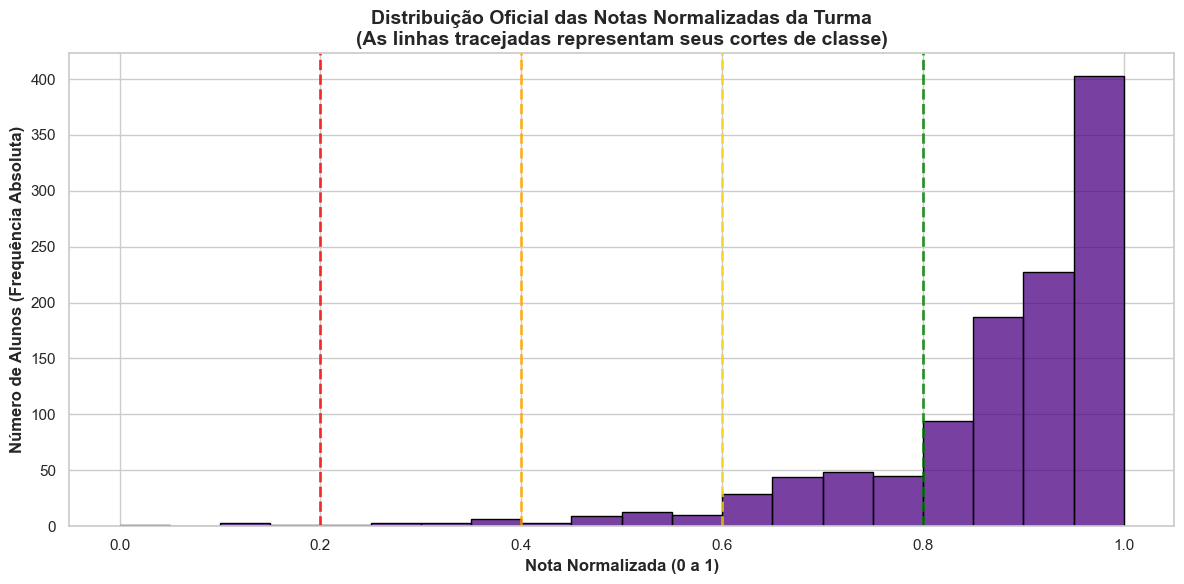


📉 Resumo Estatístico do Desempenho da Turma:


,count,mean,std,min,25%,50%,75%,max
nota_media_normalizada,1130.0,0.877937,0.142415,0.0,0.83,0.9178,0.983334,1.0


In [10]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analisar_distribuicao_notas(pasta_dados="export/"):
    print("📊 Extraindo e normalizando as Notas Finais Oficiais...")
    
    query = f"""
        SELECT 
            username,
            MAX(CAST(finalgrade AS FLOAT)) AS nota_final_bruta,
            MAX(CAST(rawgrademax AS FLOAT)) AS nota_maxima_possivel
        FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)
        WHERE itemid = '20559' 
          AND finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL
          AND username NOT IN {usuarios_ignorados}
        GROUP BY username
    """
    
    df_notas = duckdb.query(query).df()
    
    # ==========================================
    # 🔒 NORMALIZAÇÃO COM PROTEÇÃO DE LIMITES
    # A função clip(0, 1) garante que notas negativas virem 0 
    # e notas bônus maiores que o limite virem 1.0 cravado.
    # ==========================================
    df_notas['nota_media_normalizada'] = (df_notas['nota_final_bruta'] / df_notas['nota_maxima_possivel']).clip(0, 1)
    
    # ==========================================
    # 📈 PLOTAGEM DA DISTRIBUIÇÃO
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Histograma para ver a concentração de alunos
    sns.histplot(
        df_notas['nota_media_normalizada'], 
        bins=20, 
        kde=False, 
        color='indigo', 
        edgecolor='black'
    )
    
    # Marcações dos seus limites de classes (0.2, 0.4, 0.6, 0.8)
    cortes = [0.2, 0.4, 0.6, 0.8]
    cores_cortes = ['red', 'orange', 'gold', 'green']
    
    for corte, cor in zip(cortes, cores_cortes):
        plt.axvline(x=corte, color=cor, linestyle='--', linewidth=2, alpha=0.8)
    
    plt.title('Distribuição Oficial das Notas Normalizadas da Turma\n(As linhas tracejadas representam seus cortes de classe)', fontweight='bold', fontsize=14)
    plt.xlabel('Nota Normalizada (0 a 1)', fontweight='bold', fontsize=12)
    plt.ylabel('Número de Alunos (Frequência Absoluta)', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # 📋 RESUMO ESTATÍSTICO
    # ==========================================
    print("\n📉 Resumo Estatístico do Desempenho da Turma:")
    display(df_notas['nota_media_normalizada'].describe().to_frame().T)
    
    return df_notas

# Executa a análise
df_target_final = analisar_distribuicao_notas()

In [11]:
def validar_cruzamento_json_vs_20569(pasta_dados="export/", arquivo_json="pontuacao.json"):
    print("🔍 Iniciando a comparação cruzada entre o JSON (Transformador) e o Moodle (ID 20569)...")
    
    # ==========================================
    # 1. CARREGAR E NORMALIZAR O JSON
    # ==========================================
    try:
        df_json = pd.read_json(arquivo_json)
        df_json = df_json.rename(columns={'usuario': 'username'})
        
        # Normalizar para 0 a 1 (dividindo pela base 10)
        df_json['nota_json_norm'] = (df_json['pontuacao'] / 10.0).clip(0, 1)
        df_json = df_json[['username', 'nota_json_norm']]
    except FileNotFoundError:
        print(f"❌ Erro: O arquivo {arquivo_json} não foi encontrado. Verifique o caminho.")
        return None

    # ==========================================
    # 2. EXTRAIR E NORMALIZAR O MOODLE (ID 20569)
    # ==========================================
    query = f"""
        SELECT 
            username,
            MAX(CAST(finalgrade AS FLOAT)) AS nota_bruta_20569,
            MAX(CAST(rawgrademax AS FLOAT)) AS max_20569
        FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)
        WHERE itemid = '20569' 
          AND finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL
          AND username NOT IN ('0', '-1', '', 'nan', 'user6442803380426375169', 'user8540069828419911681')
        GROUP BY username
    """
    df_moodle = duckdb.query(query).df()
    
    # Normalizar para 0 a 1 (dividindo o que o aluno tirou pelo máximo possível do item 20569)
    df_moodle['nota_moodle_norm'] = (df_moodle['nota_bruta_20569'] / df_moodle['max_20569']).clip(0, 1)
    df_moodle = df_moodle[['username', 'nota_moodle_norm', 'nota_bruta_20569']]

    # ==========================================
    # 3. CRUZAMENTO (INNER JOIN) E CÁLCULO DE ERRO
    # ==========================================
    # O inner join garante que só analisaremos quem o seu transformador conseguiu mapear
    df_comparativo = pd.merge(df_json, df_moodle, on='username', how='inner')
    
    # Calcula a diferença absoluta entre a nota extraída e a nota original
    df_comparativo['diferenca_abs'] = np.abs(df_comparativo['nota_json_norm'] - df_comparativo['nota_moodle_norm'])
    
    print(f"✅ Cruzamento concluído! {len(df_comparativo)} alunos alinhados perfeitamente entre as bases.")
    
    # ==========================================
    # 4. PLOTAGEM DE VALIDAÇÃO
    # ==========================================
    plt.figure(figsize=(8, 8))
    
    sns.scatterplot(
        data=df_comparativo, 
        x='nota_moodle_norm', 
        y='nota_json_norm', 
        alpha=0.5, 
        color='teal',
        edgecolor='black'
    )
    
    # A "Linha de Identidade": Se o transformador for perfeito, todos os pontos ficarão em cima dela
    plt.plot([0, 1], [0, 1], color='darkred', linestyle='--', linewidth=2, label='Alinhamento Exato (JSON = Moodle)')
    
    plt.title('Validação de Transformador: JSON vs Moodle (ID 20569)', fontweight='bold', fontsize=14)
    plt.xlabel('Desempenho Moodle - ID 20569 (0 a 1)', fontweight='bold')
    plt.ylabel('Desempenho JSON - Transformador (0 a 1)', fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. DIAGNÓSTICO DE DESVIOS
    # ==========================================
    print("\n📉 Resumo Estatístico do 'Erro' de Extração (Diferença Absoluta):")
    display(df_comparativo['diferenca_abs'].describe().to_frame().T)
    
    print("\n🧐 Top 10 Alunos com Maior Divergência (Investigar o pipeline JSON nestes casos):")
    display(df_comparativo.sort_values(by='diferenca_abs', ascending=False).head(10))

    return df_comparativo

# Executa a validação
df_validacao_join = validar_cruzamento_json_vs_20569()

🔍 Iniciando a comparação cruzada entre o JSON (Transformador) e o Moodle (ID 20569)...
❌ Erro: O arquivo pontuacao.json não foi encontrado. Verifique o caminho.


🔍 Iniciando a comparação cruzada entre o JSON (Transformador) e o Moodle (ID 20569)...
✅ Cruzamento concluído! 831 alunos alinhados perfeitamente entre as bases.


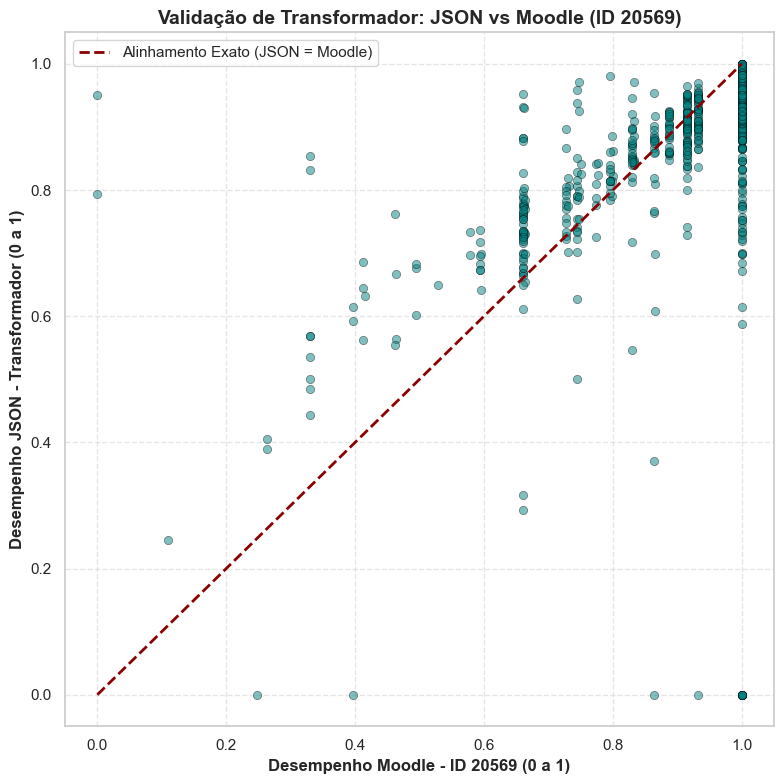


📉 Resumo Estatístico do 'Erro' de Extração (Diferença Absoluta):
               count      mean       std  min    25%    50%    75%  max
diferenca_abs  831.0  0.077801  0.127768  0.0  0.022  0.043  0.081  1.0

🧐 Top 10 Alunos com Maior Divergência (Investigar o pipeline JSON nestes casos):
       username  nota_json_norm  nota_moodle_norm  nota_bruta_20569  \
825  aluno_1192            0.00             1.000         80.000000   
38    aluno_266            0.00             1.000         80.000000   
535  aluno_1416            0.00             1.000         80.000000   
483    aluno_97            0.00             1.000         80.000000   
315  aluno_1665            0.00             1.000         80.000000   
789  aluno_1112            0.00             1.000         80.000000   
201  aluno_1634            0.00             1.000         80.000000   
105  aluno_1632            0.00             1.000         80.000000   
422  aluno_1433            0.95             0.000          0.000000  

In [12]:
def validar_cruzamento_json_vs_20569(pasta_dados="export/", arquivo_json="pontuacao.json"):
    print("🔍 Iniciando a comparação cruzada entre o JSON (Transformador) e o Moodle (ID 20569)...")
    
    # ==========================================
    # 1. CARREGAR E NORMALIZAR O JSON
    # ==========================================
    try:
        df_json = pd.read_json(f"{pasta_dados}{arquivo_json}")
        df_json = df_json.rename(columns={'usuario': 'username'})
        
        # Normalizar para 0 a 1 (dividindo pela base 10)
        df_json['nota_json_norm'] = (df_json['pontuacao'] / 10.0).clip(0, 1)
        df_json = df_json[['username', 'nota_json_norm']]
    except FileNotFoundError:
        print(f"❌ Erro: O arquivo {arquivo_json} não foi encontrado. Verifique o caminho.")
        return None

    # ==========================================
    # 2. EXTRAIR E NORMALIZAR O MOODLE (ID 20569)
    # ==========================================
    query = f"""
        SELECT 
            username,
            MAX(CAST(finalgrade AS FLOAT)) AS nota_bruta_20569,
            MAX(CAST(rawgrademax AS FLOAT)) AS max_20569
        FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)
        WHERE itemid = '20569' 
          AND finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL
          AND username NOT IN ('0', '-1', '', 'nan', 'user6442803380426375169', 'user8540069828419911681')
        GROUP BY username
    """
    df_moodle = duckdb.query(query).df()
    
    # Normalizar para 0 a 1 (dividindo o que o aluno tirou pelo máximo possível do item 20569)
    df_moodle['nota_moodle_norm'] = (df_moodle['nota_bruta_20569'] / df_moodle['max_20569']).clip(0, 1)
    df_moodle = df_moodle[['username', 'nota_moodle_norm', 'nota_bruta_20569']]

    # ==========================================
    # 3. CRUZAMENTO (INNER JOIN) E CÁLCULO DE ERRO
    # ==========================================
    # O inner join garante que só analisaremos quem o seu transformador conseguiu mapear
    df_comparativo = pd.merge(df_json, df_moodle, on='username', how='inner')
    
    # Calcula a diferença absoluta entre a nota extraída e a nota original
    df_comparativo['diferenca_abs'] = np.abs(df_comparativo['nota_json_norm'] - df_comparativo['nota_moodle_norm'])
    
    print(f"✅ Cruzamento concluído! {len(df_comparativo)} alunos alinhados perfeitamente entre as bases.")
    
    # ==========================================
    # 4. PLOTAGEM DE VALIDAÇÃO
    # ==========================================
    plt.figure(figsize=(8, 8))
    
    sns.scatterplot(
        data=df_comparativo, 
        x='nota_moodle_norm', 
        y='nota_json_norm', 
        alpha=0.5, 
        color='teal',
        edgecolor='black'
    )
    
    # A "Linha de Identidade": Se o transformador for perfeito, todos os pontos ficarão em cima dela
    plt.plot([0, 1], [0, 1], color='darkred', linestyle='--', linewidth=2, label='Alinhamento Exato (JSON = Moodle)')
    
    plt.title('Validação de Transformador: JSON vs Moodle (ID 20569)', fontweight='bold', fontsize=14)
    plt.xlabel('Desempenho Moodle - ID 20569 (0 a 1)', fontweight='bold')
    plt.ylabel('Desempenho JSON - Transformador (0 a 1)', fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. DIAGNÓSTICO DE DESVIOS
    # ==========================================
    print("\n📉 Resumo Estatístico do 'Erro' de Extração (Diferença Absoluta):")
    print(df_comparativo['diferenca_abs'].describe().to_frame().T)
    
    print("\n🧐 Top 10 Alunos com Maior Divergência (Investigar o pipeline JSON nestes casos):")
    print(df_comparativo.sort_values(by='diferenca_abs', ascending=False).head(10))

    return df_comparativo

# Executa a validação
df_validacao_join = validar_cruzamento_json_vs_20569()

⏳ Iniciando processamento dos timeouts padrão...
 ✅ Timeout de 1h concluído. Média: 0.81h | Timeouts forçados: 78.1%
 ✅ Timeout de 2h concluído. Média: 1.15h | Timeouts forçados: 72.0%
 ✅ Timeout de 3h concluído. Média: 1.34h | Timeouts forçados: 67.1%
 ✅ Timeout de 4h concluído. Média: 1.52h | Timeouts forçados: 63.3%
 ✅ Timeout de 5h concluído. Média: 1.70h | Timeouts forçados: 60.7%
 ✅ Timeout de 6h concluído. Média: 1.87h | Timeouts forçados: 58.5%
 ✅ Timeout de 7h concluído. Média: 2.04h | Timeouts forçados: 56.8%
 ✅ Timeout de 8h concluído. Média: 2.22h | Timeouts forçados: 55.1%
 ✅ Timeout de 9h concluído. Média: 2.39h | Timeouts forçados: 53.5%
 ✅ Timeout de 10h concluído. Média: 2.58h | Timeouts forçados: 51.9%
 ✅ Timeout de 11h concluído. Média: 2.75h | Timeouts forçados: 50.3%
 ✅ Timeout de 12h concluído. Média: 2.93h | Timeouts forçados: 48.9%
 ✅ Timeout de 13h concluído. Média: 3.10h | Timeouts forçados: 47.6%
 ✅ Timeout de 14h concluído. Média: 3.33h | Timeouts forçados: 

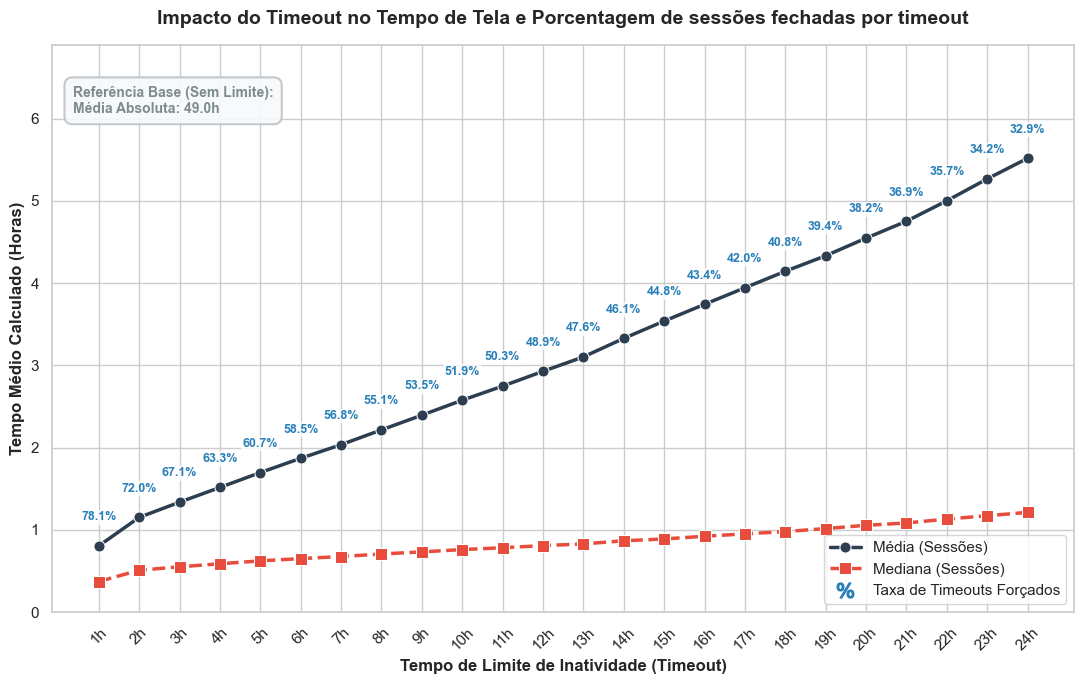

In [13]:

%load_ext autoreload
%autoreload 2
from modulos.metrica_tempo_total_gasto_em_visitas_reais import calcular_tempo_total_gasto_em_visitas_reais

statements = load_statements_from_file("xapi_statements_completos.json", folder=".")

def analisar_impacto_timeout(statements, horas_teste=[1, 2, 4, 8, 12, 18, 24], folder="export/"):
    resultados = []
    
    print("⏳ Iniciando processamento dos timeouts padrão...")
    for h in horas_teste:
        timeout_min = h * 60
        arquivo_temp = f"{folder}tempo_temp_timeout_{h}h.json"
        
        calcular_tempo_total_gasto_em_visitas_reais(
            statements=statements, 
            caminho_arquivo_saida=arquivo_temp, 
            timeout_minutos=timeout_min
        )
        
        with open(arquivo_temp, 'r', encoding='utf-8') as f:
            dados = json.load(f)
            
        tempos_horas = [sessao.get('tempo_passado_segundos', 0) / 3600 for sessao in dados]
        
        # Contabilidade do Timeout
        total_sessoes = len(dados)
        sessoes_timeout = sum(1 for d in dados if d.get("motivo_encerramento") == "timeout")
        pct_timeout = (sessoes_timeout / total_sessoes * 100) if total_sessoes > 0 else 0
        
        if tempos_horas:
            media_horas = np.mean(tempos_horas)
            mediana_horas = np.median(tempos_horas)
        else:
            media_horas, mediana_horas = 0, 0
            
        resultados.append({
            "Timeout (Horas)": h,
            "Timeout Categoria": f"{h}h",
            "Média (Horas)": media_horas,
            "Mediana (Horas)": mediana_horas,
            "Total Sessões": total_sessoes,
            "Sessões Timeout": sessoes_timeout,
            "% Timeout": pct_timeout
        })
        print(f" ✅ Timeout de {h}h concluído. Média: {media_horas:.2f}h | Timeouts forçados: {pct_timeout:.1f}%")
        
    df_resultados = pd.DataFrame(resultados)
    
    # Cálculo Sem Timeout
    print("⏳ Calculando o cenário de Referência (Sem Timeout)...")
    arquivo_infinito = folder + "tempo_temp_timeout_infinito.json"
    
    calcular_tempo_total_gasto_em_visitas_reais(
        statements=statements, 
        caminho_arquivo_saida=arquivo_infinito, 
        timeout_minutos=999999 
    )
    
    with open(arquivo_infinito, 'r', encoding='utf-8') as f:
        dados_inf = json.load(f)
        
    tempos_horas_inf = [aluno.get('tempo_passado_segundos', 0) / 3600 for aluno in dados_inf]
    media_sem_timeout = np.mean(tempos_horas_inf) if tempos_horas_inf else 0
    
    print(f" 🎯 Cenário Sem Timeout concluído. Média irreal de: {media_sem_timeout:.2f}h.")
    
    return df_resultados, media_sem_timeout

# ==========================================
# EXECUÇÃO E GERAÇÃO DA VISUALIZAÇÃO
# ==========================================
horas_para_testar = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
df_tempos, media_irreal_sem_timeout = analisar_impacto_timeout(statements, horas_para_testar)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7)) # Gráfico levemente ampliado para acomodar as anotações

# Plota as linhas de Média e Mediana
ax = sns.lineplot(
    data=df_tempos, x="Timeout Categoria", y="Média (Horas)", 
    marker="o", linewidth=2.5, markersize=8, label="Média (Sessões)", color="#2c3e50"
)
sns.lineplot(
    data=df_tempos, x="Timeout Categoria", y="Mediana (Horas)", 
    marker="s", linewidth=2.5, markersize=8, label="Mediana (Sessões)", color="#e74c3c", linestyle="--"
)


# Adicionando a linha de referência do cenário "Sem Timeout"
handles, labels = ax.get_legend_handles_labels()
handles.append(
    Line2D(
        [0], [0],
        marker='$\\%$',
        linestyle='',
        markersize=12,
        color='#2980b9',
        label='Porcentagem de Timeouts'
    )
)
labels.append('Taxa de Timeouts Forçados')

plt.legend(handles=handles, labels=labels, frameon=True, fontsize=11, loc="lower right")

# Adicionando a porcentagem de timeouts acima de cada marcação
for i, row in df_tempos.iterrows():
    ax.text(
        x=i, 
        y=row["Média (Horas)"] + (df_tempos["Média (Horas)"].max() * 0.05), # Gap adaptável acima do ponto
        s=f'{row["% Timeout"]:.1f}%', 
        ha='center', va='bottom', fontsize=9, color="#2980b9", fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
    )


# Caixa de Informação do Cenário "Sem Timeout"
bbox_props = dict(boxstyle="round,pad=0.6", fc="#f8f9fa", ec="#bdc3c7", lw=1.5, alpha=0.9)
plt.annotate(
    f"Referência Base (Sem Limite):\nMédia Absoluta: {media_irreal_sem_timeout:.1f}h",
    xy=(0.02, 0.88), 
    xycoords='axes fraction',
    fontsize=10,
    color="#7f8c8d",
    fontweight='bold',
    bbox=bbox_props
)

plt.title("Impacto do Timeout no Tempo de Tela e Porcentagem de sessões fechadas por timeout", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tempo de Limite de Inatividade (Timeout)", fontsize=12, fontweight='bold')
plt.ylabel("Tempo Médio Calculado (Horas)", fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
# Expande o topo do gráfico para evitar que a última anotação corte
y_max = df_tempos["Média (Horas)"].max()
plt.ylim(bottom=0, top=y_max * 1.25) 

plt.tight_layout()
plt.show()